### Geographic Distance Notebook for Development Testing

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from ecd_helperFunctions import *

In [ ]:
# Load in CSV as dataframe
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S2.csv')

# Calculate GD for each ROI
gd, cell_count_dict, bboxes, mantel_dict = calculate_gd(df=sample_df, 
                            perturb_matrix=True,
                            return_bboxes=True,
                            roi_tile_size=500)

print(bboxes)
print(gd)
print(mantel_dict)
print(cell_count_dict)


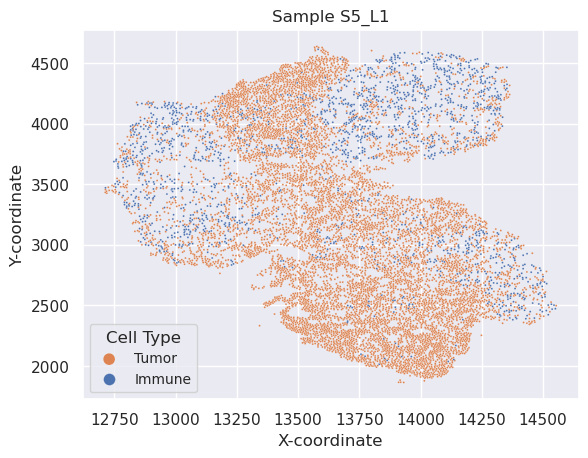

In [14]:
# Plotting
sample_df = pd.read_csv('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/data/P2_BTC/S5_L1.csv')
sns.set_theme(style='darkgrid')  # Set the aesthetic style of the plots
sns.scatterplot(data=sample_df, x='x_centroid', y='y_centroid', s=2, hue='tumor_immune')  # Plot points
plt.legend(title='Cell Type', labels=['Tumor', 'Immune'], loc='lower left', fontsize=10, markerscale=6)
plt.xlabel('X-coordinate')  # Optional: Set the x-axis label
plt.ylabel('Y-coordinate')  # Optional: Set the y-axis label
plt.title('Sample S5_L1')  # Optional: Set the plot title
plt.savefig('/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/original_scatter/s5_l1_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

Adjusted explanation value range: -0.041694110551345046 to 0.4050994766856817


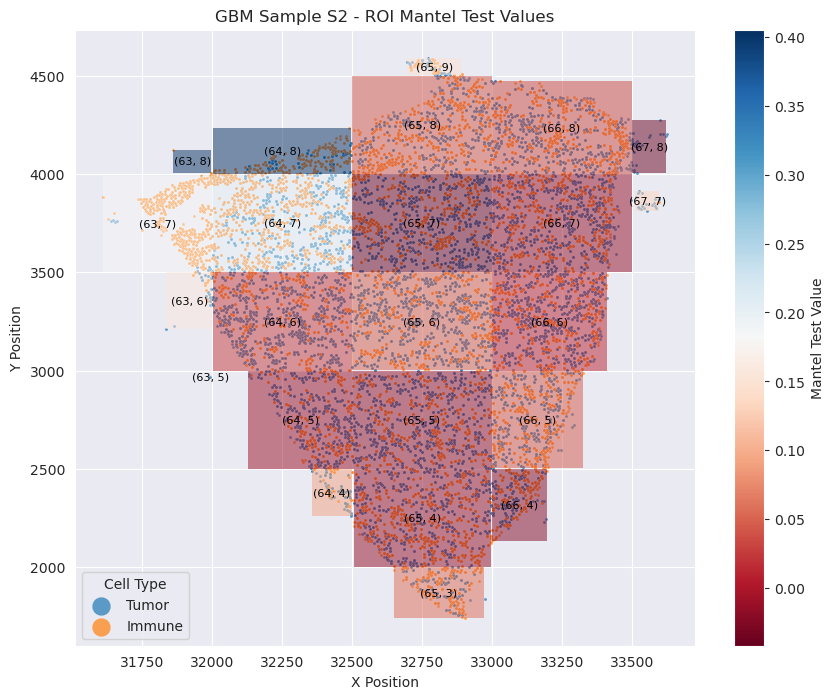

In [83]:
# Plot Heatmap with Explainer Values

# Define custom legend and scatter plot options
legend_options = {
    'title': 'Cell Type',
    'markerscale': 6,
    'loc': 'lower left',
    'fontsize': 10
}

scatter_options = {
    's': 5,
    'zorder': 2,
    'alpha': 0.7  # Additional scatter plot options
}

# Call the function with custom options
plot_roi_explanations(
    data_dict=mantel_dict,
    sample_df=sample_df,
    bboxes=bboxes,
    legend_kwargs=legend_options,
    scatter_kwargs=scatter_options,
    title='GBM Sample S2 - ROI Mantel Test Values',
    save_path='/home/ecdyer/labshare/PROJECTS/SPATIAL_STATS/figures/heatmaps/s2_smallroi_cell_positions_with_mantel_values.png',
    dpi=300,
    bbox_inches='tight'
)


In [87]:
immune_cell_count = cell_count_dict[1]   
tumor_cell_count = cell_count_dict[0]
# Calculate the weighted statistic
weighted_statistic = compute_weighted_statistic(statistics=mantel_dict.values(),
                                                  cell_counts_type_A=immune_cell_count,
                                                  cell_counts_type_B=tumor_cell_count)

print(weighted_statistic)

0.06324290903302555
